# Austin 911 Police Dispatch Call Volume Prediction

### Predicting hourly police dispatch demand using random forest regression

**Author:** Katherine Flannery

**Dataset:** City of Austin APD Computer Aided Dispatch Incidents

**Analysis Period:** 2022-2025

## Project Overview

This project uses historical Austin Police Department Computer Aided Dispatch incident data to predict hourly police dispatch call volume using a random forest regression model.

The goal was to determine whether temporal patterns and recent historical call volumes could provide useful predictions of future 911 demand. A dummy regressor was used as a baseline to determine whether the machine learning model provided meaningful improvement over a simple average-based prediction.

The final random forest regression model outperformed the baseline dummy regressor, reducing the mean absolute error from 10.48 calls per hour to 6.37 calls per hour and achieving an $R^2$ of 0.58 on the held-out test set.




## Research Question

To what extent can temporal and historical call-volume features predict 911 police dispatch hourly call volume using a Random Forest regression model?



## Data

The project utilizes one publicly available dataset, APD Computer Aided Dispatch Incidents, provided by the City of Austin on the data.gov website.

The file includes historical incident-level data for 911 calls involving police dispatch in the city of Austin in a CSV format.

The original dataset contains:

* 4,082,993 incident records
* 27 variables
* Historical records from 2017-June 2026

The analysis uses a subset of the last four full years, 2022-2025. The original incident-level records were aggregated into a continuous hourly time series. Hours with no calls were retained and assigned a call volume of zero.

In [2]:
# Import required libraries.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import holidays
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats


In [ ]:
#Import dataset and display dataframe information.
df= pd.read_csv("/content/APD_Computer_Aided_Dispatch_Incidents.csv", engine='python')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4082993 entries, 0 to 4082992
Data columns (total 27 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   Incident Number               int64  
 1   Incident Type                 object 
 2   Council District              int64  
 3   Mental Health Flag            object 
 4   Priority Level                object 
 5   Response Datetime             object 
 6   Response Year                 int64  
 7   Response Month                object 
 8   Response Day of Week          object 
 9   Response Hour                 int64  
 10  First Unit Arrived Datetime   object 
 11  Call Closed Datetime          object 
 12  Sector                        object 
 13  Initial Problem Description   object 
 14  Initial Problem Category      object 
 15  Final Problem Description     object 
 16  Final Problem Category        object 
 17  Number of Units Arrived       float64
 18  Unit Time on Scene    

## Data Cleaning and Preparation



In [ ]:
# Rename columns to remove spaces and capitals
df.rename(columns={"Incident Number": "incident_number", "Incident Type": "incident_type", "Council District": "council_district", "Mental Health Flag": "mental_health_flag", "Priority Level": "priority_level", "Response Datetime": "response_datetime", "Response Year": "response_year", "Response Month":"response_month", "Response Day of Week": "response_day_of_week", "Response Hour": "response_hour", "First Unit Arrived Datetime": "first_unit_arrived_datetime", "Call Closed Datetime": "call_closed_datetime", "Sector": "sector", "Initial Problem Description": "initial_problem_description", "Initial Problem Category": "initial_problem_category", "Final Problem Description": "final_problem_description", "Final Problem Category": "final_problem_category", "Number of Units Arrived": "number_units_arrived", "Unit Time on Scene": "unit_time_on_scene", "Call Disposition Description": "call_disposition_description", "Report Written Flag": "report_written_flag", "Response Time": "response_time", "Officer Injured/Killed Count": "officer_injured_killed_count", "Subject Injured/Killed Count": "subject_injured_killed_count", "Other Injured/Killed Count": "other_injured_killed_count", "Geo ID": "geo_id", "Census Block Group": "census_block_group"}, inplace=True)

print(df.head())
calls_per_year=df['incident_number'].groupby(df['response_year']).count()
print(f'Calls per year: {calls_per_year}')

   incident_number               incident_type  council_district  \
0        210980596         Dispatched Incident                 9   
1        213000367         Dispatched Incident                 2   
2        212640257         Dispatched Incident                 9   
3        212741590  Officer-Initiated Incident                 1   
4        212051341         Dispatched Incident                10   

           mental_health_flag priority_level       response_datetime  \
0  Not Mental Health Incident     Priority 2  04/08/2021 10:10:40 AM   
1  Not Mental Health Incident     Priority 0  10/27/2021 07:25:48 AM   
2      Mental Health Incident     Priority 2  09/21/2021 08:15:48 AM   
3  Not Mental Health Incident     Priority 3  10/01/2021 10:02:54 PM   
4  Not Mental Health Incident     Priority 2  07/24/2021 07:14:08 PM   

   response_year response_month response_day_of_week  response_hour  \
0           2021            Apr                  Thu             10   
1           2021

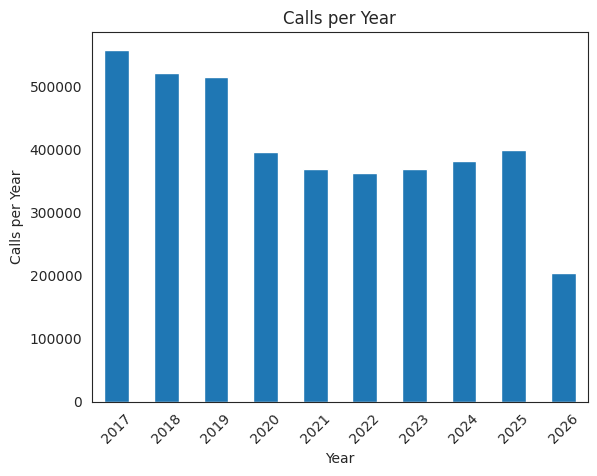

In [ ]:
# Set style for plots
sns.set_style('white')

# Plot the number of calls per year
fig, ax = plt.subplots()
calls_per_year.plot(kind='bar')
plt.title('Calls per Year')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.ylabel('Calls per Year')
plt.show()

In [ ]:
# Create a subset of the data including the last 4 full years (2022-2025).
target_years = [2022, 2023, 2024, 2025]
df2=df[df['response_year'].isin(target_years)].copy()

# Set column display to show all the columns
pd.set_option('display.max_columns', None)

# Check duplicates
print(f'Duplicate rows: {df2.duplicated().sum()}')

#Null values
NullVals= df2.isnull().sum().to_frame()
print(f'Null Values: {NullVals}')

Duplicate rows: 0
Null Values:                                    0
incident_number                    0
incident_type                      0
council_district                   0
mental_health_flag                 0
priority_level                     0
response_datetime                  0
response_year                      0
response_month                     0
response_day_of_week               0
response_hour                      0
first_unit_arrived_datetime        0
call_closed_datetime               0
sector                             0
initial_problem_description        0
initial_problem_category           0
final_problem_description          0
final_problem_category             0
number_units_arrived               1
unit_time_on_scene                33
call_disposition_description       0
report_written_flag                0
response_time                 365541
officer_injured_killed_count       0
subject_injured_killed_count       0
other_injured_killed_count         0
geo_id 

No duplicate values were identified. Missing values were present in unit_time_on_scene, response_time, geo_id, and census_block_group. Because these variables are not required for the final model, no action is taken on the null values.

Hourly call volume is created by aggregating incident_number grouped by the response_datetime. Hours with no calls are filled with a 0.

Response hour, month, year and day of the week are extracted from the response_datetime. A variable to denote if a date is a weekend is created using the response_day_of_week variable.

A variable to denote if a date is a U.S. holiday is created using the holidays package.

Lag variables for 168 hours (1 week) and 24 hours (1 day) are created using shift() and the rows with the null values are dropped to prepare the data for the random forest model.

In [ ]:
# Calculate hourly call volume
df2["response_datetime"] = pd.to_datetime(df2["response_datetime"], format='%m/%d/%Y %I:%M:%S %p')

hourly_calls = (
    df2.groupby(pd.Grouper(key="response_datetime", freq="h"))
      .size()
      .rename("call_volume")
)

full_range = pd.date_range(
    start="2022-01-01 00:00",
    end="2025-12-31 23:00",
    freq='h'
)
# Fill missing hours with 0
hourly_calls = (
    hourly_calls
    .reindex(full_range, fill_value=0)
    .rename_axis("response_datetime")
    .reset_index()
)

# Create columns for reponse hour, month, year, and day of week
hourly_calls['response_hour']=hourly_calls['response_datetime'].dt.hour
hourly_calls['response_month']=hourly_calls['response_datetime'].dt.month
hourly_calls['response_year']=hourly_calls['response_datetime'].dt.year
hourly_calls['response_day_of_week']=hourly_calls['response_datetime'].dt.dayofweek

# Create variable for denoting if it is a weekend.
hourly_calls['is_weekend']=np.where(hourly_calls['response_day_of_week'].isin([5,6]), 1, 0)

# Create list of US holiday dates in the years 2022-2025
us_holidays = holidays.US()
hourly_calls['is_holiday'] = hourly_calls['response_datetime'].isin(us_holidays).astype(int)

# Ensure chronological order
hourly_calls = hourly_calls.sort_values('response_datetime')

# Create lag variables for 24 hours, and 168 hours.
hourly_calls['volume_lag_24_hr']=hourly_calls['call_volume'].shift(24)
hourly_calls['volume_lag_168_hr']=hourly_calls['call_volume'].shift(168)

# Drop the rows with null values created by the lag.
hourly_calls=hourly_calls.dropna()

## Exploratory Data Analysis

The analysis visualizes the hourly call volume, average calls per hour, average calls by day of the week, and the call volume over the first two weeks in the dataset.

In [ ]:
hourly_calls['call_volume'].describe()

,call_volume
count,34896.000000
mean,43.260975
std,13.601683
min,0.000000
25%,34.000000
50%,44.000000
75%,53.000000
max,117.000000


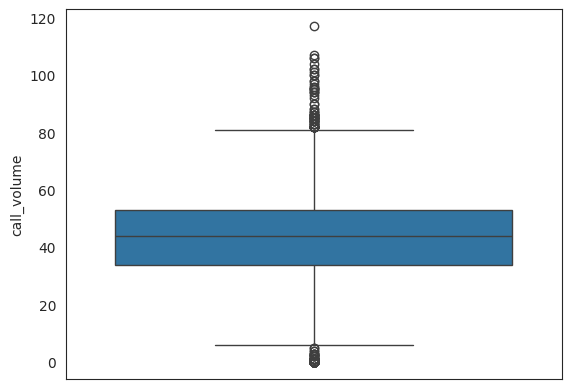

In [ ]:
ax=sns.boxplot(hourly_calls['call_volume'])
plt.show()

Text(0, 0.5, 'Count')

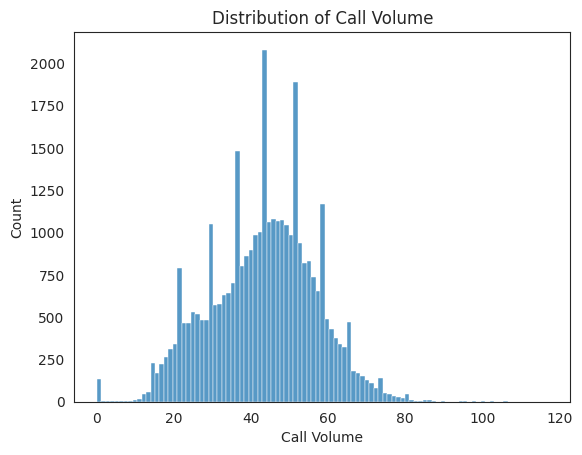

In [ ]:
# Distribution of Call Volume
ax=sns.histplot(hourly_calls['call_volume'])
ax.set_title('Distribution of Call Volume')
ax.set_xlabel('Call Volume')
ax.set_ylabel('Count')


Hourly call volume averaged 43.26 calls, with a maximum of 117 calls per hour. 75% of the hourly call volumes are less than or equal to 53 calls per hour.

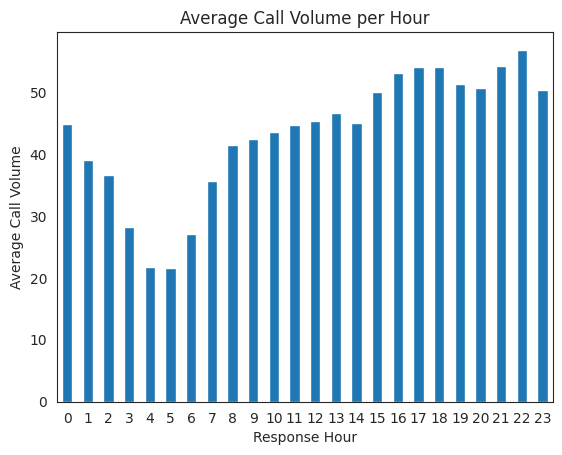

In [ ]:
# Plot for average call volume per hour
fig, ax = plt.subplots()
calls_per_hour= hourly_calls['call_volume'].groupby(hourly_calls['response_hour']).mean()
calls_per_hour.plot(kind='bar')
plt.title('Average Call Volume per Hour')
plt.xlabel('Response Hour')
plt.ylabel('Average Call Volume')
plt.xticks(rotation=0)
plt.show()

The average call volume is not uniform throughout the day. Between the hours of 3 a.m. and 6 a.m. the hourly call volume is lower than average, indicating fewer staff and resources needed. Between the hours of 3 p.m. and 11 p.m. the hourly call volume is highest requiring more staff.


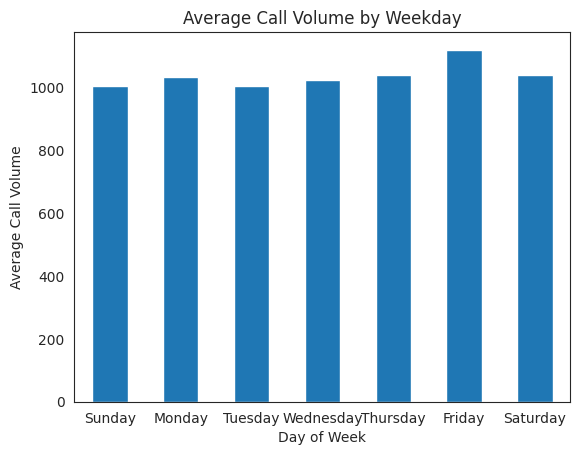

In [ ]:
# Daily totals
daily = hourly_calls.groupby(hourly_calls['response_datetime'].dt.date)['call_volume'].sum()

# Convert index back to datetime
daily.index = pd.to_datetime(daily.index)

# Average daily total by weekday
avg_by_weekday = daily.groupby(daily.index.day_name()).mean()

# Set day order for x-axis and plot
day_order=['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
ax = avg_by_weekday.loc[day_order].plot(kind="bar", legend=False)
ax.set_title('Average Call Volume by Weekday')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Call Volume')
plt.xticks(rotation=0)
plt.show()


The average daily call volume by the day of the week is fairly uniform with an increase in calls on Fridays.

Text(0.5, 1.0, 'Call Volume Over Time')

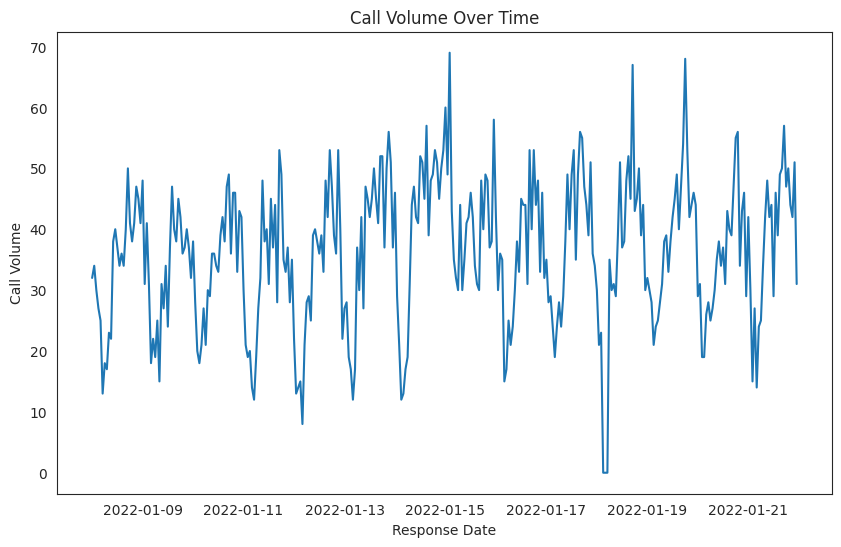

In [ ]:
# Time series plot first two weeks of call volume
two_weeks=hourly_calls.iloc[:336]
fig, ax = plt.subplots( figsize = (10,6))
ax.plot(two_weeks['response_datetime'], two_weeks['call_volume'])
ax.set_xlabel('Response Date')
ax.set_ylabel('Call Volume')
ax.set_title('Call Volume Over Time')


The hourly call volume appears to follow a cyclical trend over a 24-hour period with some variation between days. Most of the call volumes fall between 20 to 50 calls per hour.
The reoccurring pattern suggests that hour of day may be a strong predictor to the call volume for days that do not deviate from the typical call volumes.


## Encoding


In [ ]:
# Cyclical Encoding for response_hour

# Month cyclical encoding
hourly_calls['month_sin']=np.sin(2*np.pi*hourly_calls['response_month']/12)
hourly_calls['month_sin']=np.cos(2*np.pi*hourly_calls['response_month']/12)

# Day of week cyclical encoding
hourly_calls['weekday_sin']=np.sin(2*np.pi*hourly_calls['response_day_of_week']/7)
hourly_calls['weekday_cos']=np.cos(2*np.pi*hourly_calls['response_day_of_week']/7)

# Hourly cyclical encoding
hourly_calls['hour_sin']=np.sin(2*np.pi*hourly_calls['response_hour']/24)
hourly_calls['hour_cos']=np.cos(2*np.pi*hourly_calls['response_hour']/24)

## Train/Test Split

In [ ]:
#Set X and y values.
columns_to_drop = ['call_volume', 'response_datetime', 'response_hour', 'response_month', 'response_day_of_week']

X = hourly_calls.drop(columns=columns_to_drop, axis=1)
y = hourly_calls['call_volume']

#Calculate split indices
holdout_size=24+336
train_end = int(len(hourly_calls)- holdout_size)

#Training data
X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

#Test data
X_test= X.iloc[-336:]
y_test = y.iloc[-336:]

# Time series split
tscv=TimeSeriesSplit(n_splits=5, gap=24, test_size=336)
for i, (train_index, test_index) in enumerate(tscv.split(X_train)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")

Fold 0:
  Train: index=[    0     1     2 ... 32829 32830 32831]
  Test:  index=[32856 32857 32858 32859 32860 32861 32862 32863 32864 32865 32866 32867
 32868 32869 32870 32871 32872 32873 32874 32875 32876 32877 32878 32879
 32880 32881 32882 32883 32884 32885 32886 32887 32888 32889 32890 32891
 32892 32893 32894 32895 32896 32897 32898 32899 32900 32901 32902 32903
 32904 32905 32906 32907 32908 32909 32910 32911 32912 32913 32914 32915
 32916 32917 32918 32919 32920 32921 32922 32923 32924 32925 32926 32927
 32928 32929 32930 32931 32932 32933 32934 32935 32936 32937 32938 32939
 32940 32941 32942 32943 32944 32945 32946 32947 32948 32949 32950 32951
 32952 32953 32954 32955 32956 32957 32958 32959 32960 32961 32962 32963
 32964 32965 32966 32967 32968 32969 32970 32971 32972 32973 32974 32975
 32976 32977 32978 32979 32980 32981 32982 32983 32984 32985 32986 32987
 32988 32989 32990 32991 32992 32993 32994 32995 32996 32997 32998 32999
 33000 33001 33002 33003 33004 33005 33006 3

## Model Development



In [ ]:
# Create the random forest regressor
model = RandomForestRegressor(random_state=42)

#Create the grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    n_jobs=-1,
    cv=tscv,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    verbose=3
)
grid_search.fit(X_train, y_train)

#Get best params
best_params=grid_search.best_params_
print("Best Params: ")
print(best_params)

#Get best estimator
best_model=grid_search.best_estimator_
print(best_model)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Params: 
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
RandomForestRegressor(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                      n_estimators=200, random_state=42)


**Best Params:** 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
RandomForestRegressor(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                      n_estimators=200, random_state=42


The best model is used to make predictions on the unseen test dataset and calculate the mean absolute error (MAE), mean squared error (MSE), and $R^2$ for the random forest regressor.


In [ ]:
#Make predictions
y_grid_pred=best_model.predict(X_test)


print("\nBest Model MAE on Test Data:", mean_absolute_error(y_test, y_grid_pred))
print("\nBest Model MSE on Test Data:", mean_squared_error(y_test, y_grid_pred))
print("\nBest Model R2 on Test Data:", r2_score(y_test, y_grid_pred))


Best Model MAE on Test Data: 6.372300934888306

Best Model MSE on Test Data: 69.86888257852007

Best Model R2 on Test Data: 0.5801955289831455


In [ ]:
dummy_reg = DummyRegressor(strategy='mean')
#Fit the dummy model on the data
dummy_reg.fit(X_train, y_train)

dummy_pred=dummy_reg.predict(X_test)

print("\nDummy Model MAE on Test Data:", mean_absolute_error(y_test, dummy_pred))
print("\nDummy Model MSE on Test Data:", mean_squared_error(y_test, dummy_pred))
print("\nDummy Model R2 on Test Data:", r2_score(y_test, dummy_pred))



Dummy Model MAE on Test Data: 10.479708544293326

Dummy Model MSE on Test Data: 167.5460377545976

Dummy Model R2 on Test Data: -0.006693869355834048


## Model Performance

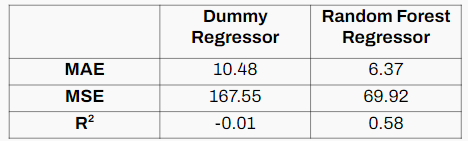

The Random Forest Regressor outperformed the dummy regressor. The MAE for the dummy regressor is approximately 10.48 compared to approximately 6.37 with the random forest regressor. The final random forest regressor model predicted hourly call volume within approximately 6 calls, an improvement of approximately 4 calls from the dummy regressor model.

The dummy regressor shows an $R^2$ value of -0.01 indicating that the proportion of variance explained by the regression model is extremely close to 0. The random forest regressor has an $R^2$ of 0.58, indicating that 58% of the variance is explained by the model. The difference in $R^2$ values between the two models is approximately 58%.


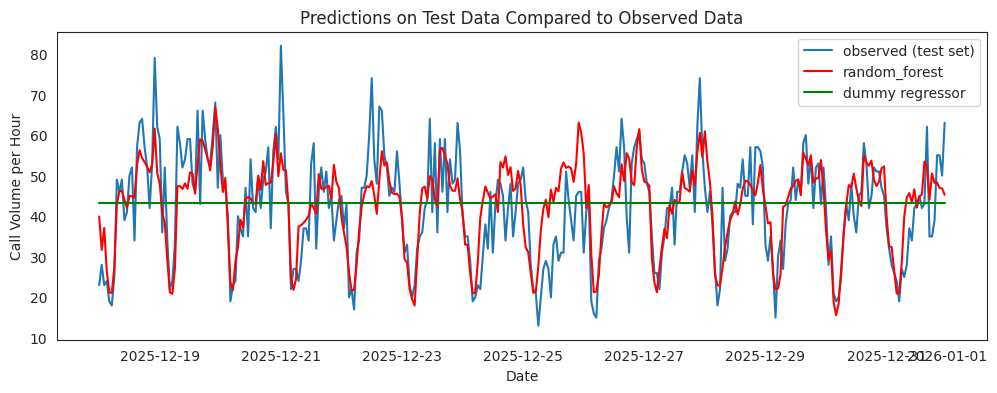

In [ ]:
# Create plot comparing predictions of both models to the observed data
plt.figure(figsize=(12,4))
plt.plot(hourly_calls['response_datetime'].iloc[-336:], y_test, label='observed (test set)')
#plot random forest predictions
plt.plot(hourly_calls['response_datetime'].iloc[-336:], y_grid_pred, color='r', label='random_forest')
plt.plot(hourly_calls['response_datetime'].iloc[-336:], dummy_pred, color='g', label='dummy regressor')

plt.title('Predictions on Test Data Compared to Observed Data')
plt.xlabel('Date')
plt.ylabel('Call Volume per Hour')
plt.legend()
plt.show()


The plot shows the observed call volumes in the test dataset in blue, the random forest model predictions in red, and the dummy regressor predictions in green.

The dummy regressor always outputs the mean of the training data, and therefore is a flat line.
The random forest model underpredicts on several occasions.

## Statistical Comparison

The analysis performs a paired t-test to determine whether the Random Forest Regressor model improvement in the MAE is statistically significant utilizing the ttest_rel from scipy.stats. The test compares the mean absolute errors of the dummy regressor and the random forest regressor with the alternative hypothesis that the dummy regressor mean absolute error is greater than the mean absolute error of the random forest regressor.

The test statistic is approximately 9.19 with a p-value of 2.168808403631742e-18.

The random forest significantly outperforms the dummy regressor.

In [ ]:
dummy_errors = np.abs(y_test - dummy_pred)
rf_errors = np.abs(y_test - y_grid_pred)

# Perform a paired t-test
t_stat, p_value = stats.ttest_rel(dummy_errors, rf_errors, alternative='greater')

print(f"t-statistic: {t_stat}")
print(f"p-value: {p_value}")

if p_value < 0.05:
    print("Reject the null hypothesis. The Random Forest significantly outperforms the Dummy Regressor.")
else:
    print("Fail to reject the null hypothesis. No significant difference detected.")

t-statistic: 9.186871462558637
p-value: 2.168808403631742e-18
Reject the null hypothesis. The Random Forest significantly outperforms the Dummy Regressor.


## Feature Importance

The one-week lag was the mode influential feature, suggesting that call volume at the same hour one week earlier contains useful information about current demand. Hour-based cyclical features were also among the most influential predictors.

             Feature  Importance
4  volume_lag_168_hr    0.642710
8           hour_sin    0.112895
3   volume_lag_24_hr    0.107681
9           hour_cos    0.056900
6        weekday_sin    0.024971
5          month_sin    0.017502
0      response_year    0.014453
7        weekday_cos    0.012490
1         is_weekend    0.010399
2         is_holiday    0.000000


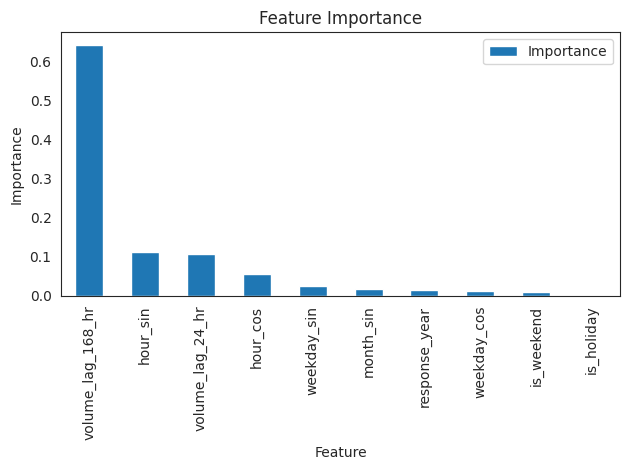

In [ ]:
#Get feature importances
importances=best_model.feature_importances_
feat_imp_df= pd.DataFrame({'Feature': X.columns, 'Importance':importances}).sort_values('Importance', ascending=False)
top_10 = feat_imp_df.head(10)
print(top_imp)

top_10.plot(x='Feature', y='Importance', kind='bar')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()